In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.tail()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
df.shape

(301, 9)

In [6]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(2)

In [11]:
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(299, 9)

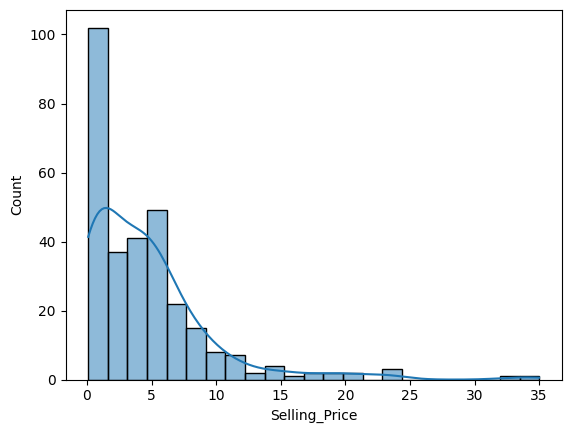

In [13]:
sns.histplot(df['Selling_Price'], kde=True)
plt.show()

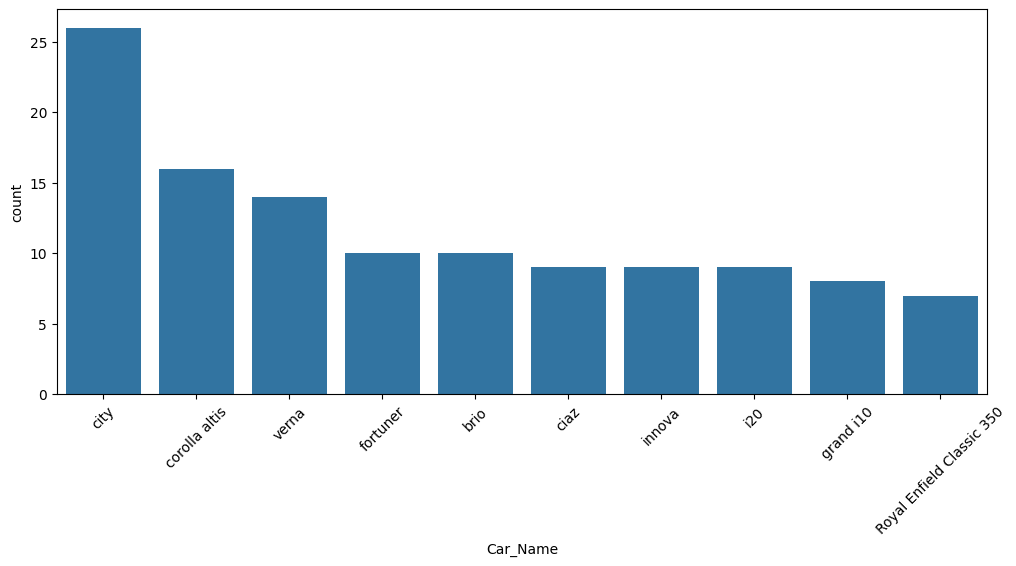

In [14]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x='Car_Name',
    order=df['Car_Name'].value_counts().head(10).index
)

plt.xticks(rotation=45)
plt.show()

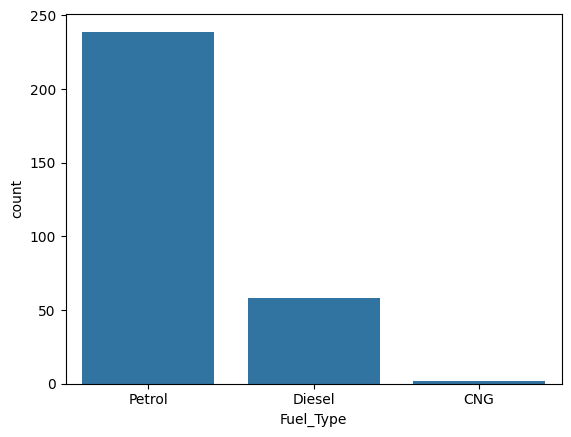

In [15]:
sns.countplot(data=df,x='Fuel_Type')
plt.show()

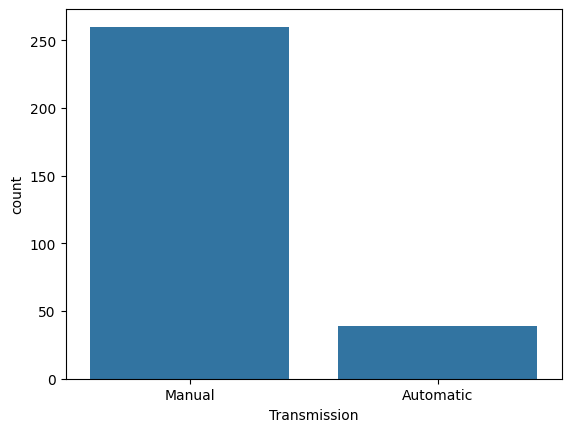

In [16]:
sns.countplot(data=df,x='Transmission')
plt.show()

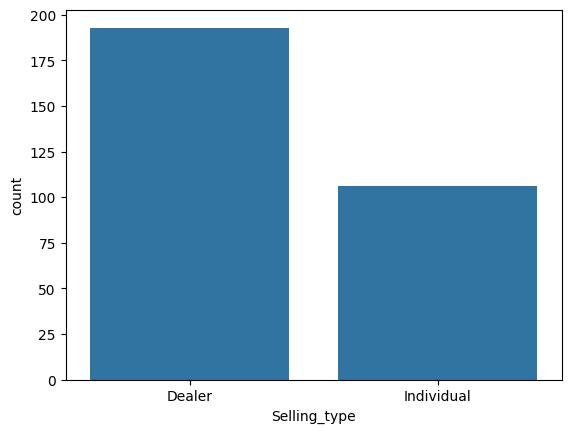

In [17]:
sns.countplot(data=df,x='Selling_type')
plt.show()

In [18]:
df['Car_Age'] = 2025 - df['Year']

In [19]:
df.drop('Year',axis=1,inplace=True)

In [20]:
df.drop('Car_Name',axis=1,inplace=True)

In [21]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [22]:
df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,11,False,True,False,True
1,4.75,9.54,43000,0,12,True,False,False,True
2,7.25,9.85,6900,0,8,False,True,False,True
3,2.85,4.15,5200,0,14,False,True,False,True
4,4.60,6.87,42450,0,11,True,False,False,True


In [23]:
X = df.drop('Selling_Price',axis=1)

y = df['Selling_Price']

In [24]:
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred_lr = lr.predict(X_test)

In [27]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train,y_train)

y_pred_dt = dt.predict(X_test)

In [28]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train,y_train)

y_pred_rf = rf.predict(X_test)

In [29]:
def evaluate(y_test,pred):

    print("MAE :",mean_absolute_error(y_test,pred))

    print("MSE :",mean_squared_error(y_test,pred))

    print("RMSE :",np.sqrt(mean_squared_error(y_test,pred)))

    print("R2 :",r2_score(y_test,pred))

In [30]:
evaluate(y_test,y_pred_lr)

MAE : 1.4725457508178643
MSE : 6.3731251062607095
RMSE : 2.524504923001876
R2 : 0.7527233824220485


In [31]:
evaluate(y_test,y_pred_dt)

MAE : 1.1085
MSE : 4.433641666666667
RMSE : 2.1056214442930306
R2 : 0.8279751461635348


In [32]:
evaluate(y_test,y_pred_rf)

MAE : 1.4656383333333347
MSE : 12.317244055166675
RMSE : 3.5095931466719437
R2 : 0.5220921609005125


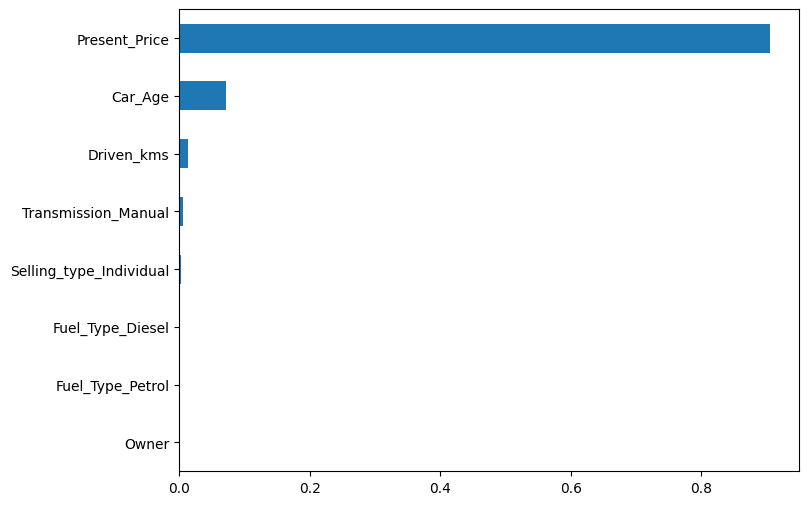

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.show()

In [34]:
sample = [[5.59, 27000, 0, 11, 0, 1, 0, 1]]

In [35]:
print(X.columns)

Index(['Present_Price', 'Driven_kms', 'Owner', 'Car_Age', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol', 'Selling_type_Individual', 'Transmission_Manual'],
      dtype='str')


In [36]:
print(rf.feature_names_in_)

['Present_Price' 'Driven_kms' 'Owner' 'Car_Age' 'Fuel_Type_Diesel'
 'Fuel_Type_Petrol' 'Selling_type_Individual' 'Transmission_Manual']


In [37]:
sample = [[5.59, 27000, 0, 11, 0, 1, 0, 1]]

In [38]:
rf.predict(sample)

array([3.5815])

In [39]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred_rf
})

comparison.head(10)

,Actual Price,Predicted Price
283,8.99,9.5021
267,8.35,8.2800
166,0.45,0.4424
9,7.45,6.9180
78,5.25,17.2575
280,5.25,5.3155
95,5.85,6.8465
111,1.15,1.1775
5,9.25,7.8660
175,0.38,0.2820


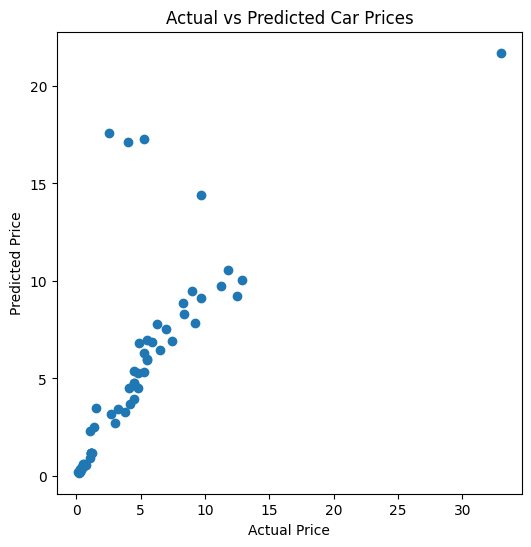

In [40]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()

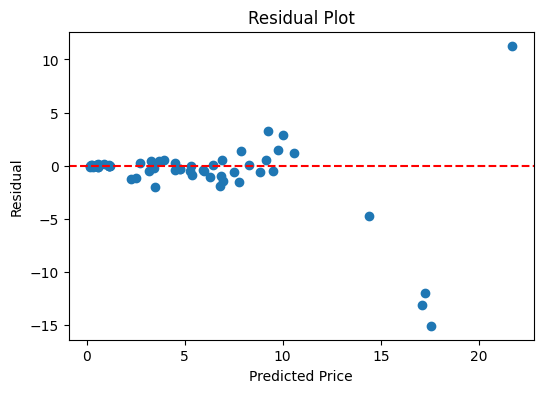

In [41]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,4))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

In [42]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False)

print(importance)

Present_Price              0.904397
Car_Age                    0.071972
Driven_kms                 0.013325
Transmission_Manual        0.005996
Selling_type_Individual    0.002313
Fuel_Type_Diesel           0.001313
Fuel_Type_Petrol           0.000678
Owner                      0.000006
dtype: float64


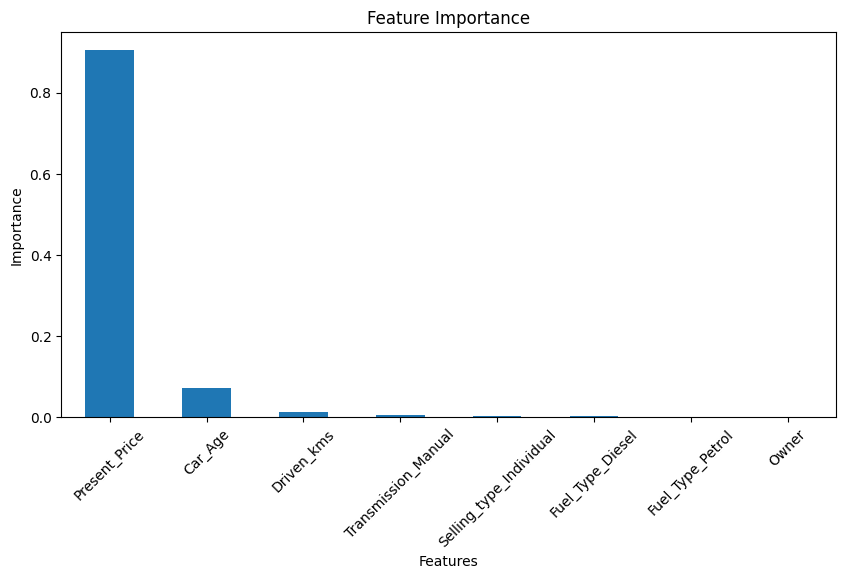

In [43]:
importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [44]:
import pickle

pickle.dump(rf, open("Car_Price_Model.pkl", "wb"))

In [45]:
import os

os.listdir()

['.ipynb_checkpoints',
 'car data.csv',
 'Car_Price.ipynb',
 'car_price_model.pkl']

In [46]:
loaded_model = pickle.load(open("Car_Price_Model.pkl", "rb"))

In [47]:
loaded_model.predict(sample)

array([3.5815])